# Abordagem Avançada: Filtros Gaussianos e Binarização de Sauvola

**Objetivo:** Este notebook implementa um pipeline de processamento de imagem melhorado, utilizando técnicas mais avançadas para obter um resultado final mais limpo e preciso.

As melhorias principais são:
1. **Filtro Notch Gaussiano:** Em vez de um filtro de corte abrupto, usamos um filtro Gaussiano que atenua suavemente as frequências de ruído. Isto **reduz os "ringing artifacts"** (ondulações) na imagem reconstruída, resultando num fundo mais limpo.
2. **Binarização de Sauvola:** Em vez da binarização adaptativa padrão, usamos o método de Sauvola. Este algoritmo é mais robusto para texto em documentos com iluminação e contraste variáveis, pois considera tanto a média de intensidade local quanto o desvio padrão. Isto ajuda a **preservar melhor a integridade das letras**, evitando que se partam ou se juntem.

In [13]:
import cv2
import numpy as np
import utils as utl
from matplotlib import pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['image.cmap'] = 'gray'

### Passos 1 a 3: Carregamento, Análise de Frequência e Deteção de Picos

Estes passos iniciais são idênticos ao método anterior. Carregamos a imagem, analisamos o seu espectro de frequência e detetamos os picos de ruído.

In [14]:
# 1. Carregar Imagem
image_path = '../assets\Letters-noisy.png'
img_original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 2. Análise de Frequência
dft = cv2.dft(np.float32(img_original), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)

# 3. Deteção de Picos
norm_spectrum = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
_, picos_img = cv2.threshold(norm_spectrum, 150, 255, cv2.THRESH_BINARY)

# Visualização dos passos iniciais (opcional, pode descomentar para ver)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8))
# ax1.imshow(img_original)
# ax1.set_title('Original')
# ax2.imshow(picos_img)
# ax2.set_title('Picos de Ruído Detetados')
# plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:2: SyntaxWarning: invalid escape sequence '\L'
C:\Users\paulo\AppData\Local\Temp\ipykernel_41792\1097493473.py:2: SyntaxWarning: invalid escape sequence '\L'
  image_path = '../assets\Letters-noisy.png'


### Passo 4 (Avançado): Criação do Filtro Notch Gaussiano

Aqui está a primeira grande diferença. Criamos uma máscara que, em vez de ter "buracos" de valor zero, tem atenuações Gaussianas centradas nos picos de ruído. O filtro é de rejeição de banda (band-reject), então a fórmula para cada pico é `1 - G(u,v)`, onde `G(u,v)` é uma Gaussiana 2D.

8 pares de filtros Notch Gaussianos aplicados.


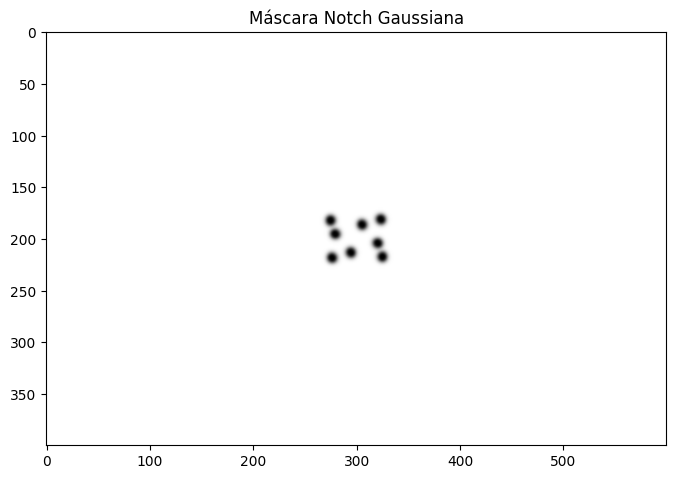

<Figure size 800x800 with 0 Axes>

In [ ]:
def criar_mascara_notch_gaussiana(shape, picos_img, D0):
    """Cria uma máscara de rejeição de banda Gaussiana a partir dos picos."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    
    # Começa com uma máscara que deixa passar tudo (valor 1)
    mascara = np.ones((rows, cols), dtype=np.float32)
    
    # Encontra os picos
    contours, _ = cv2.findContours(picos_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Não filtrar o componente DC (centro)
    min_dist_centro = 5

    # Cria a grade de coordenadas uma única vez
    u, v = np.meshgrid(np.arange(cols), np.arange(rows))

    count = 0
    for cnt in contours:
        M = cv2.moments(cnt)
        if M['m00'] == 0: continue
        
        cX = int(M['m10'] / M['m00'])
        cY = int(M['m01'] / M['m00'])
        
        dist_centro = np.sqrt((cX - ccol)**2 + (cY - crow)**2)
        if dist_centro < min_dist_centro:
            continue

        # Calcula a distância de cada ponto do grid ao pico atual
        D_sq = (u - cX)**2 + (v - cY)**2
        # Cria o filtro de rejeição Gaussiano para este pico
        filtro_pico = 1.0 - np.exp(-D_sq / (2 * D0**2))
        # Multiplica na máscara principal
        mascara *= filtro_pico
        
        # Faz o mesmo para o pico simétrico
        cX_sim = 2 * ccol - cX
        cY_sim = 2 * crow - cY
        D_sq_sim = (u - cX_sim)**2 + (v - cY_sim)**2
        filtro_pico_sim = 1.0 - np.exp(-D_sq_sim / (2 * D0**2))
        mascara *= filtro_pico_sim

        count += 1
    
    print(f"{count} pares de filtros Notch Gaussianos aplicados.")
    return mascara


# D0 controla a "largura" do filtro Gaussiano. 
D0_gauss = 3
mascara_gaussiana = criar_mascara_notch_gaussiana(img_original.shape, picos_img, D0_gauss)

# A máscara final precisa ter 2 canais para ser aplicada ao DFT
mascara_final = np.zeros((img_original.shape[0], img_original.shape[1], 2), dtype=np.float32)
mascara_final[:, :, 0] = mascara_gaussiana
mascara_final[:, :, 1] = mascara_gaussiana

plt.imshow(mascara_gaussiana)
plt.title('Máscara Notch Gaussiana')
plt.show()

### Passo 5 e 6: Filtragem, Reconstrução e Remoção de Ruído Sal e Pimenta

O processo de aplicação do filtro e reconstrução é o mesmo, mas agora usamos a máscara Gaussiana. Depois, aplicamos o filtro de mediana como antes.

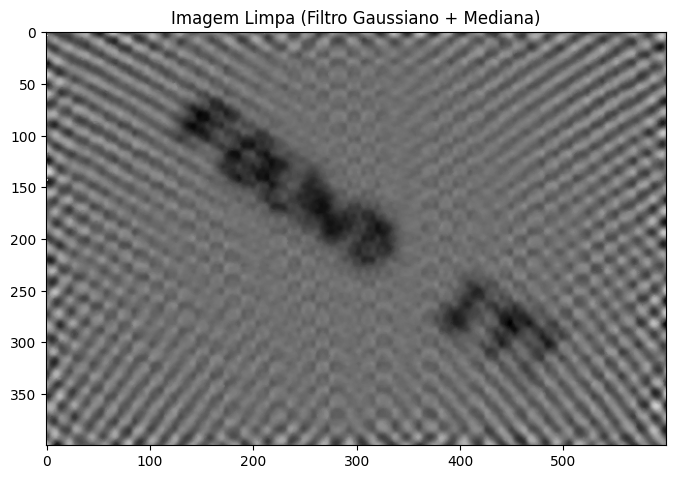

In [16]:
# 5. Aplicação do filtro e reconstrução
fshift_filtrado = dft_shift * mascara_final
f_ishift = np.fft.ifftshift(fshift_filtrado)
img_filtrada_freq = cv2.idft(f_ishift)
img_filtrada_freq = cv2.magnitude(img_filtrada_freq[:, :, 0], img_filtrada_freq[:, :, 1])
cv2.normalize(img_filtrada_freq, img_filtrada_freq, 0, 255, cv2.NORM_MINMAX)
img_filtrada_freq = np.uint8(img_filtrada_freq)

# 6. Remoção de ruído sal e pimenta
img_limpa = cv2.medianBlur(img_filtrada_freq, 3)

plt.imshow(img_limpa)
plt.title('Imagem Limpa (Filtro Gaussiano + Mediana)')
plt.show()

### Passo 7 (Avançado): Binarização de Sauvola

Esta é a segunda grande melhoria. O método de Sauvola calcula um limiar local para cada pixel baseado na média e no desvio padrão da sua vizinhança. A fórmula é:

`T = media * (1 + k * ((desvio_padrao / R) - 1))`

- `k`: Parâmetro que controla o quão influente é o desvio padrão. Valores entre 0.2 e 0.5 são comuns.
- `R`: O valor máximo do desvio padrão (tipicamente 128 para imagens de 8 bits).
- `window_size`: O tamanho da vizinhança para calcular a média e o desvio padrão.

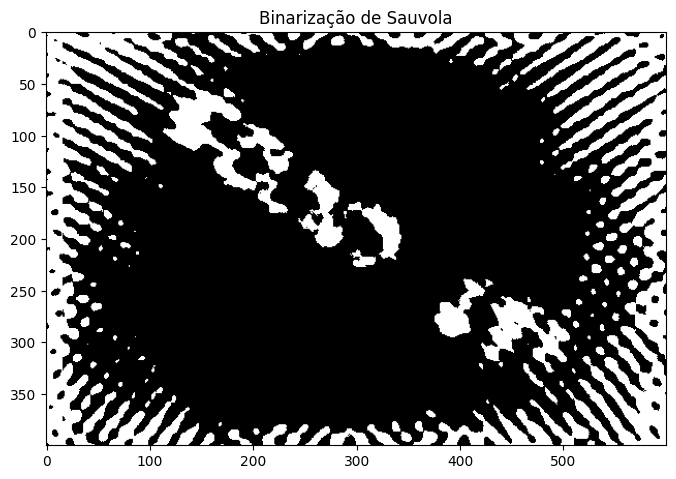

In [17]:
def binarizacao_sauvola(img, window_size=300, k=128, R=11):
    """Implementação da binarização de Sauvola."""
    # Garante que a imagem é float para os cálculos
    img = img.astype(np.float32)
    
    # Calcula a média local e a média dos quadrados
    mean = cv2.blur(img, (window_size, window_size))
    mean_sq = cv2.blur(img**2, (window_size, window_size))
    
    # Calcula o desvio padrão local
    std = np.sqrt(mean_sq - mean**2)
    
    # Calcula o limiar de Sauvola
    threshold = mean * (1 + k * ((std / R) - 1))
    
    # Cria a imagem binarizada. Como queremos texto branco, a lógica é invertida.
    # Pixels mais escuros que o limiar viram 255 (branco).
    output = np.zeros_like(img, dtype=np.uint8)
    output[img < threshold] = 255
    
    return output

img_binarizada_sauvola = binarizacao_sauvola(img_limpa, window_size=31, k=0.3)

plt.imshow(img_binarizada_sauvola)
plt.title('Binarização de Sauvola')
plt.show()

### Passo 8: Deteção de Contornos (Canny)

O passo final permanece o mesmo: aplicamos o detector de Canny à imagem binarizada para extrair os contornos finais das letras.

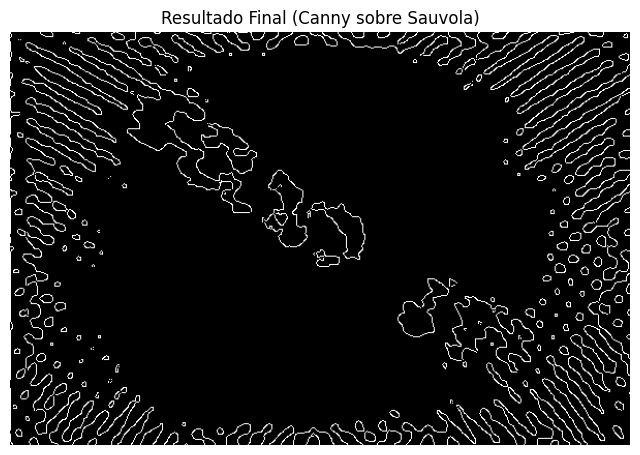

In [18]:
edges = cv2.Canny(img_binarizada_sauvola, 0, 200)

plt.imshow(edges)
plt.title('Resultado Final (Canny sobre Sauvola)')
plt.axis('off')
plt.show()

### Conclusão

Ao comparar os resultados, espera-se que esta abordagem avançada produza contornos de letras mais completos e um fundo com menos artefactos. A suavidade do filtro Gaussiano e a inteligência local do método de Sauvola combinam-se para um resultado superior na recuperação de texto de imagens degradadas.